In [60]:
import pandas as pd

df = pd.read_csv("/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/cleaned_data/cleaned_data.csv")
df.head()

,Rating,Company Name,Industry,Sector,mean_salary,seniority,job_role,log_revenue,company_age,size_category
0,3.1,healthfirst3.1,insurance carriers,insurance,154000.0,senior,data scientist,19.519293,33.0,medium
1,4.2,mantech4.2,research development,business services,154000.0,mid,data scientist,21.128731,58.0,large
2,3.8,analysis group3.8,consulting,business services,154000.0,mid,data scientist,19.519293,45.0,medium
3,3.5,inficon3.5,electrical electronic manufacturing,manufacturing,154000.0,mid,data scientist,19.519293,26.0,medium
4,2.9,affinity solutions2.9,advertising marketing,business services,154000.0,mid,data scientist,19.519293,28.0,small


In [61]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["mean_salary"])
y = df["mean_salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42
)


In [62]:
# Colonnes numériques
num_features = ['company_age', "Rating"]

# Colonnes catégorielles (faible cardinalité)
cat_features = ['Industry', 'Sector', 'size_category',"log_revenue", "seniority", "job_role"]

# Colonnes texte (haute cardinalité / texte libre) → à encoder différemment
text_features = ['Company Name']

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numérique : imputer + scaler
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Catégoriel : imputer + OHE
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [64]:
from sklearn.compose import ColumnTransformer
'''from sklearn.feature_extraction.text import TfidfVectorizer 

# Texte : TF-IDF (pour Job Title surtout, Job Description optionnel) 
title_transformer = TfidfVectorizer(max_features=50, ngram_range=(1,2)) 
desc_transformer = TfidfVectorizer(max_features=100, stop_words='english') '''
preprocessor = ColumnTransformer(transformers=[ 
    ('num', num_transformer, num_features), 
    ('cat', cat_transformer, cat_features), 
     ],
    remainder='drop') # drop Company Name (trop de cardinalité)

In [65]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([ 
    ('preprocessor', preprocessor), 
    ('regressor', RandomForestRegressor(
        n_estimators=100,

        random_state=42)) ]) 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [66]:
y_pred = model.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 26058.86802213859
R²  : -0.08733637478583467


In [68]:
import joblib

joblib.dump(model, "/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/model/hr_ai_platform.pkl")

['/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/model/hr_ai_platform.pkl']

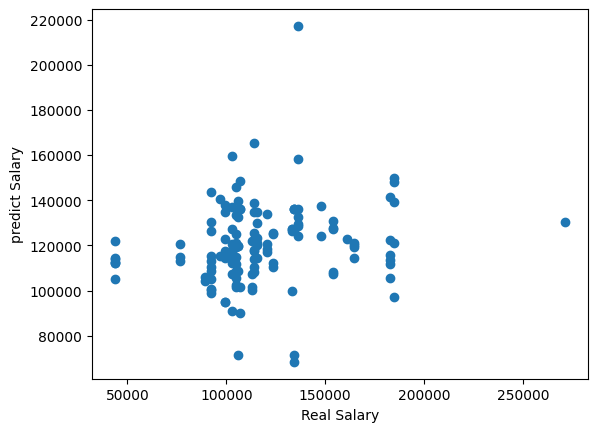

In [69]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Real Salary")
plt.ylabel("predict Salary")
plt.show()

In [70]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.568073859206517
Test R²: -0.08733637478583467
